This version of get_relevant_datasets aims to merge the two approached already created to search for relevant datasets: the one from get_relevant_datasets_v1 and the one from testing_dspy_agent_v0.

This will enable us to combine the best of both **DSPy** and a **Vector Database** that we created using NEON DB.
The workflow will work as follows:

To be done once:

*   Embed all datasets using the gouv.fr api
*   Fill the NEON DB with all dataset embeddings and information

Regular workflow:
*   Get user question (as a string)
*   Feed user question into DSPy agent
*   DSPy agent will inject additional information into the user question (e.g., a translation of the user question into French, keywords that the LLM is asked to add based on the quetion, a timestamp of the current time and date) to make the search process easier and more accurate
*   Once the augmented user query is created, it will be fed into the NEON database (which would have already been created and filled with all the datasets and their information + embeddings of all the datasets) to search (using cosine similarity) for the **most related databases**. It will then:
*   Return the list of the top k relevant datasets based on the user query.


In [35]:
!pip -q install requests psycopg[binary] pgvector openai azure-core

In [36]:
import os
from google.colab import userdata

# Azure OpenAI
os.environ["AZURE_OPENAI_ENDPOINT"] = "https://o3miniapi.openai.azure.com/"
os.environ["AZURE_OPENAI_API_KEY"] = userdata.get('Azure')
os.environ["AZURE_OPENAI_EMBED_DEPLOYMENT"] = "text-embedding-3-small"
os.environ["AZURE_OPENAI_CHAT_DEPLOYMENT"] = "gpt-5-mini"

# Neon (optional for now)
os.environ["NEON_DATABASE_URL"] = userdata.get("Neon")  # put your Neon URL in Colab secrets



Next code block is for functions to fill out the NEON DB with chosen dataset embeddings and also function to search for similar datasets given a user quesion (using cosine similarity)

In [37]:
from __future__ import annotations

import os
import time
import json
from dataclasses import dataclass
from typing import Any, Dict, Iterable, List, Optional, Sequence, Set, Tuple

import requests

from openai import AzureOpenAI

# Postgres / pgvector
# pip install psycopg[binary] pgvector
import psycopg
from pgvector.psycopg import register_vector


# ----------------------------
# 1) data.gouv.fr API fetching
# ----------------------------

DATASETS_URL = "https://www.data.gouv.fr/api/1/datasets/"

# openai.api_type = "azure"
# openai.api_base = os.environ["AZURE_OPENAI_ENDPOINT"]
# openai.api_key = os.environ["AZURE_OPENAI_API_KEY"]
# openai.api_version = "2024-02-01"


@dataclass
class DatasetRecord:
    id: str
    title: str
    description: str
    tags: List[str]

    def to_embedding_text(self) -> str:
        """
        Concatenate fields (excluding ID) into a single string for embeddings.
        You can tweak formatting freely.
        """
        tags_str = ", ".join(self.tags) if self.tags else ""
        title = (self.title or "").strip()
        desc = (self.description or "").strip()

        parts = []
        if title:
            parts.append(f"Title: {title}")
        if desc:
            parts.append(f"Description: {desc}")
        if tags_str:
            parts.append(f"Tags: {tags_str}")

        # Keep it stable & readable
        return "\n".join(parts).strip()



class DataGouvDatasetsClient:
    def __init__(self, base_url: str = DATASETS_URL, timeout_s: int = 60):
        self.base_url = base_url
        self.timeout_s = timeout_s
        self.session = requests.Session()
        self.session.headers.update({"Accept": "application/json"})

    def fetch_page(
        self,
        page: int = 1,
        page_size: int = 50,
        q: Optional[str] = None,
        tags: Optional[Sequence[str]] = None,  # NEW
    ) -> Dict[str, Any]:
        """
        GET /api/1/datasets/?page=...&page_size=...&q=...&tag=...&tag=...

        NOTE: 'tag' is documented as a string[] query param, meaning it can be repeated.
        """
        params: Dict[str, Any] = {"page": page, "page_size": page_size}
        if q:
            params["q"] = q
        if tags:
            # requests encodes list values as repeated query params: tag=a&tag=b
            params["tag"] = list(tags)

        resp = self.session.get(self.base_url, params=params, timeout=self.timeout_s)
        resp.raise_for_status()
        return resp.json()

    def iter_datasets(
        self,
        mode: str = "single_page",   # "single_page" or "all_pages"
        page: int = 1,
        page_size: int = 50,
        q: Optional[str] = None,
        tags: Optional[Sequence[str]] = None,      # NEW (server-side filter)
        hard_limit: Optional[int] = None,          # safety limit across all pages
        require_any_of_tags: Optional[Set[str]] = None,  # NEW (client-side OR verification)
    ) -> Iterable["DatasetRecord"]:
        """
        - single_page: fetch exactly `page`
        - all_pages: follow `next_page` until exhausted

        `tags` is passed to the API as repeated query params (tag=...).
        `require_any_of_tags` is an optional client-side OR filter for safety.
        """
        if mode not in ("single_page", "all_pages"):
            raise ValueError("mode must be 'single_page' or 'all_pages'")

        fetched = 0
        current_page = page
        next_url: Optional[str] = None

        while True:
            if next_url is None:
                payload = self.fetch_page(page=current_page, page_size=page_size, q=q, tags=tags)
            else:
                resp = self.session.get(next_url, timeout=self.timeout_s)
                resp.raise_for_status()
                payload = resp.json()

            data = payload.get("data", []) or []
            for item in data:
                rec = DatasetRecord(
                    id=str(item.get("id", "") or ""),
                    title=str(item.get("title", "") or ""),
                    description=str(item.get("description", "") or ""),
                    tags=list(item.get("tags", []) or []),
                )

                if not rec.id and not rec.title and not rec.description and not rec.tags:
                    continue

                # Optional client-side OR filter (guarantees correctness)
                if require_any_of_tags:
                    if not set(rec.tags).intersection(require_any_of_tags):
                        continue

                yield rec
                fetched += 1
                if hard_limit is not None and fetched >= hard_limit:
                    return

            if mode == "single_page":
                return

            next_url = payload.get("next_page") or None
            if not next_url:
                return

    def iter_datasets_with_any_tags(
        self,
        any_tags: Sequence[str],          # NEW: OR semantics
        mode: str = "all_pages",
        page: int = 1,
        page_size: int = 50,
        q: Optional[str] = None,
        hard_limit: Optional[int] = None,
    ) -> Iterable["DatasetRecord"]:
        """
        Guaranteed OR semantics across tags by querying once per tag and deduplicating.

        Example:
          any_tags=["tarifs-voyageurs", "gtfs", "mobilite"]
        """
        want: Set[str] = set(any_tags)
        seen_ids: Set[str] = set()
        emitted = 0

        for tag in want:
            for rec in self.iter_datasets(
                mode=mode,
                page=page,
                page_size=page_size,
                q=q,
                tags=[tag],                    # server-side filter per tag
                require_any_of_tags=want,      # safety verification (OR)
                hard_limit=None,               # we enforce hard_limit after dedupe
            ):
                if rec.id in seen_ids:
                    continue
                seen_ids.add(rec.id)
                yield rec
                emitted += 1
                if hard_limit is not None and emitted >= hard_limit:
                    return

    # NEW: fetch the *full* dataset object (this is how we get “ALL info”)
    def fetch_dataset_detail(self, dataset_id: str) -> Dict[str, Any]:
        url = f"{self.base_url}{dataset_id}/"
        resp = self.session.get(url, timeout=self.timeout_s)
        resp.raise_for_status()
        return resp.json()

# ----------------------------
# 2) Embeddings (Azure OpenAI)
# ----------------------------


class AzureEmbeddingClient:
    def __init__(
        self,
        azure_endpoint: str,
        api_key: str,
        deployment: str,                 # your Azure *deployment name*
        api_version: str = "2024-02-01", # embeddings API version
        request_batch_size: int = 64,
        max_retries: int = 6,
    ):
        self.deployment = deployment
        self.request_batch_size = request_batch_size
        self.max_retries = max_retries

        # NOTE: azure_endpoint (NOT endpoint)
        self.client = AzureOpenAI(
            azure_endpoint=azure_endpoint,
            api_key=api_key,
            api_version=api_version,
        )

    def embed_texts(self, texts: List[str]) -> List[List[float]]:
        all_embeddings: List[List[float]] = []
        total_tokens = 0
        for start in range(0, len(texts), self.request_batch_size):
            batch = texts[start : start + self.request_batch_size]
            attempt = 0
            while True:
                try:
                    resp = self.client.embeddings.create(
                        model=self.deployment,  # In Azure, model=<deployment_name>
                        input=batch,
                    )
                    total_tokens += resp.usage.total_tokens
                    # Keep order stable
                    items = sorted(resp.data, key=lambda x: x.index)
                    all_embeddings.extend([it.embedding for it in items])
                    break
                except Exception as e:
                    attempt += 1
                    if attempt > self.max_retries:
                        raise
                    sleep_s = min(2 ** attempt, 30)
                    print(f"[embed retry {attempt}/{self.max_retries}] {type(e).__name__}: {e} -> sleeping {sleep_s}s")
                    time.sleep(sleep_s)

        PRICE_PER_1M_TOKENS_USD = 0.02  # for text-embedding-3-small (OpenAI list price)
        cost_usd = total_tokens / 1_000_000 * PRICE_PER_1M_TOKENS_USD
        print("tokens used for embedding:", total_tokens, "estimated USD:", cost_usd)

        return all_embeddings



# ----------------------------
# 3) Neon Postgres + pgvector
# ----------------------------

class PgvectorStore:
    def __init__(self, postgres_url: str):
        self.postgres_url = postgres_url

    def connect(self):
        conn = psycopg.connect(self.postgres_url)

        # Make sure vector type exists BEFORE register_vector()
        with conn.cursor() as cur:
            cur.execute("CREATE EXTENSION IF NOT EXISTS vector;")
        conn.commit()

        register_vector(conn)
        return conn

    def ensure_schema(self, dim: int, table: str = "dataset_embeddings"):
        create_sql = f"""
        CREATE EXTENSION IF NOT EXISTS vector;

        CREATE TABLE IF NOT EXISTS {table} (
            dataset_id TEXT PRIMARY KEY,
            title TEXT,
            description TEXT,
            tags TEXT[],
            content TEXT NOT NULL,
            embedding VECTOR({dim}) NOT NULL,
            updated_at TIMESTAMPTZ NOT NULL DEFAULT NOW()
        );

        CREATE INDEX IF NOT EXISTS {table}_embedding_cosine_idx
          ON {table} USING hnsw (embedding vector_cosine_ops);
        """
        with self.connect() as conn:
            with conn.cursor() as cur:
                cur.execute(create_sql)
            conn.commit()

    def upsert_rows(self, rows, table: str = "dataset_embeddings"):
        upsert_sql = f"""
        INSERT INTO {table} (dataset_id, title, description, tags, content, embedding)
        VALUES (%s, %s, %s, %s, %s, %s)
        ON CONFLICT (dataset_id) DO UPDATE SET
            title = EXCLUDED.title,
            description = EXCLUDED.description,
            tags = EXCLUDED.tags,
            content = EXCLUDED.content,
            embedding = EXCLUDED.embedding,
            updated_at = NOW();
        """
        with self.connect() as conn:
            with conn.cursor() as cur:
                cur.executemany(upsert_sql, rows)
            conn.commit()

    def search(
        self,
        query_embedding: List[float],
        k: int = 10,
        table: str = "dataset_embeddings",
        any_tags: Optional[Sequence[str]] = None,
    ):
        """
        Returns top-k rows by cosine distance (smaller = more similar).
        Optionally filter to rows that overlap any of the provided tags.
        """
        sql = f"""
        SELECT
            dataset_id,
            title,
            description,
            tags,
            content,
            (embedding <=> (%s::vector)) AS distance
        FROM {table}
        WHERE (%s::text[] IS NULL OR tags && %s::text[])
        ORDER BY embedding <=> (%s::vector)
        LIMIT %s;
        """
        tag_array = list(any_tags) if any_tags else None

        with self.connect() as conn:
            with conn.cursor() as cur:
                cur.execute(sql, (query_embedding, tag_array, tag_array, query_embedding, k))
                return cur.fetchall()

In [38]:
# ----------------------------
# 4) Orchestration / main
# ----------------------------

def run_pipeline(
    mode: str = "single_page",   # "single_page" or "all_pages"
    page: int = 1,
    page_size: int = 50,
    q: Optional[str] = None,
    hard_limit: Optional[int] = None,
    any_tags: Optional[Sequence[str]] = None,  # NEW
):
    azure_endpoint = os.environ.get("AZURE_OPENAI_ENDPOINT", "")
    azure_api_key = os.environ.get("AZURE_OPENAI_API_KEY", "")
    azure_deployment = os.environ.get("AZURE_OPENAI_EMBED_DEPLOYMENT", "text-embedding-3-small")
    neon_postgres_url = os.environ.get("NEON_DATABASE_URL", "")

    if not azure_endpoint or not azure_api_key:
        raise RuntimeError("Set AZURE_OPENAI_ENDPOINT and AZURE_OPENAI_API_KEY env vars first.")

    dg = DataGouvDatasetsClient()

    # 1) fetch datasets (NEW: OR-tag mode)
    if any_tags:
        records = list(
            dg.iter_datasets_with_any_tags(
                any_tags=any_tags,
                mode="all_pages",       # OR-tag mode should generally scan all pages
                page=page,
                page_size=page_size,
                q=q,
                hard_limit=hard_limit,
            )
        )
    else:
        records = list(dg.iter_datasets(mode=mode, page=page, page_size=page_size, q=q, hard_limit=hard_limit))

    # 2) build embedding texts
    texts = [r.to_embedding_text() for r in records]

    # 3) embed
    emb_client = AzureEmbeddingClient(
        azure_endpoint=os.environ["AZURE_OPENAI_ENDPOINT"],
        api_key=os.environ["AZURE_OPENAI_API_KEY"],
        deployment=os.environ.get("AZURE_OPENAI_EMBED_DEPLOYMENT", "text-embedding-3-small"),
    )

    embeddings = emb_client.embed_texts(texts)

    if len(embeddings) != len(records):
        raise RuntimeError(f"Embedding count mismatch: {len(embeddings)} != {len(records)}")

    dim = len(embeddings[0]) if embeddings else 0
    print(f"Fetched {len(records)} datasets, embedding_dim={dim}")

    # 4) upsert into pgvector (optional)
    if neon_postgres_url:
        store = PgvectorStore(neon_postgres_url)
        store.ensure_schema(dim=dim, table="dataset_embeddings")

        rows = []
        for rec, content, emb in zip(records, texts, embeddings):
            rows.append((rec.id, rec.title, rec.description, rec.tags, content, emb))

        store.upsert_rows(rows, table="dataset_embeddings")
        print(f"Upserted {len(rows)} rows into Neon.")
    else:
        print("NEON_DATABASE_URL not set yet — skipping DB write.")

    return records, embeddings

Next code block runs the pipeline to:
- create embeddings
- store embeddings in NEON DB

YOU DO NOT NEED TO run the following code block(in fact, you SHOULD NOT run the following code block) ify you just want to find similarity between a user question at the datasets stored in the DB.

In [39]:
records, embeddings = run_pipeline(
    any_tags=["tarifs-voyageurs", "autobus", "vie-etudiante"],
    page_size=50,
    hard_limit=2000,   # optional
)

tokens used for embedding: 6563 estimated USD: 0.00013126000000000001
Fetched 31 datasets, embedding_dim=1536
Upserted 31 rows into Neon.


Next code block defines a function to search for the most relevant datasets given a user question (this will be used by the DSPy agent later).

In [40]:
def search_datasets(query: str, k: int = 5):
    emb_client = AzureEmbeddingClient(
        azure_endpoint=os.environ["AZURE_OPENAI_ENDPOINT"],
        api_key=os.environ["AZURE_OPENAI_API_KEY"],
        deployment=os.environ["AZURE_OPENAI_EMBED_DEPLOYMENT"],
    )
    q_emb = emb_client.embed_texts([query])[0]

    store = PgvectorStore(os.environ["NEON_DATABASE_URL"])
    return store.search(q_emb, k=k)

In [50]:
# hits = search_datasets("données de transport en commun GTFS en France", k=5)
# for dataset_id, title, desc, tags, content, dist in hits:
#     print(dist, title, dataset_id)

# This was just a test used to check if searach_datasets() functions properly, which it does.

The next few blocks of code contain the setup and use of a simple DSPy agent that takes a user question, adds more context to it, and uses the search_datasets() function to find the most similar datasets.

In [42]:
!pip -q install dspy-ai

In [43]:
import dspy
from datetime import datetime, timezone
from google.colab import userdata

AZURE_API_KEY = userdata.get('Azure')          # <-- put your key in Colab secrets or env var
AZURE_API_BASE = "https://o3miniapi.cognitiveservices.azure.com/"  # your endpoint
AZURE_API_VERSION = "2024-12-01-preview"
AZURE_DEPLOYMENT = "gpt-5-mini"       # <-- your chat-capable deployment name (e.g., "gpt-4o-mini")

# DSPy LM via LiteLLM Azure provider string.
# Note: provider strings can vary across LiteLLM versions; "azure/<deployment>" is the common pattern.
lm = dspy.LM(
    f"azure/{AZURE_DEPLOYMENT}",
    api_key=os.getenv("AZURE_API_KEY", ""),
    api_base=AZURE_API_BASE,
    api_version=AZURE_API_VERSION,
    model_type="chat",
    temperature=1.0,
    max_tokens=32000,
)

dspy.configure(lm=lm)

In [44]:
# for usage information

import logging

# More verbose internal logs (optional but useful)
logging.getLogger("dspy").setLevel(logging.DEBUG)  # DSPy FAQ mentions this approach. :contentReference[oaicite:1]{index=1}

# Track token usage (DSPy 2.6.16+)
dspy.configure(track_usage=True)  # usage can be read from Prediction.get_lm_usage(). :contentReference[oaicite:2]{index=2}

In [45]:
# -------- Signature --------
class PrepareQuery(dspy.Signature):
    """
    Keep the original question unchanged.
    Produce a French version:
      - If already French: minimal grammar/spelling fixes only.
      - If not French: translate to French.
    Produce 3–5 French keywords.
    """
    original_question: str = dspy.InputField()
    french_question: str = dspy.OutputField()
    keywords: List[str] = dspy.OutputField()


# -------- Agent --------
class DataGouvDatasetSearchAgent(dspy.Module):
    def __init__(self, k: int = 5, timezone: str = "America/Toronto"):
        super().__init__()
        self.k = k
        self.tz = timezone

        # Predict = no chain-of-thought, no over-reasoning
        self.prepare = dspy.Predict(PrepareQuery)

    def forward(self, question: str) -> dspy.Prediction:
        # 1) Keep question EXACTLY as-is
        original_question = question

        # 2) Translate / lightly correct + extract keywords
        prep = self.prepare(original_question=original_question)
        french_q = (prep.french_question or "").strip()

        # 3) Normalize keywords (3–5, ';' separated)
        kws = []
        for kw in (prep.keywords or []):
            kw = str(kw).strip().strip(";")
            if kw:
                kws.append(kw)
        kws = kws[:5]

        keywords_str = "; ".join(kws)

        # 4) ISO 8601 UTC timestamp with +00:00 (data.gouv.fr style)
        timestamp = datetime.now(timezone.utc).isoformat()

        # 5) Final embedded text (compact, embedding-friendly)
        embedded_text = "\n".join(
            part for part in [
                original_question,
                french_q,
                keywords_str,
                timestamp,
            ]
            if part
        )

        # 6) Vector search (your embedding + Neon cosine similarity)
        hits = search_datasets(embedded_text, k=self.k)

        return dspy.Prediction(
            original_question=original_question,
            french_question=french_q,
            keywords=kws,
            timestamp=timestamp,
            embedded_text=embedded_text,
            k=self.k,
            hits=hits,
        )

In [46]:
# 3) Example usage
agent = DataGouvDatasetSearchAgent(k=5)

result = agent(question="How many unique address points (entrées) are in Navès by street name — produce a ranked list of streets by address count and their total coordinates (geojson or CSV).")
print(result.embedded_text)
print("\nTop hits:")
for dataset_id, title, desc, tags, content, dist in result.hits:
    print(dist, title, dataset_id)

tokens used for embedding: 132 estimated USD: 2.64e-06
How many unique address points (entrées) are in Navès by street name — produce a ranked list of streets by address count and their total coordinates (geojson or CSV).
Combien y a-t-il de points d'adresse uniques (entrées) à Navès, par nom de rue — produire une liste classée des rues par nombre d'adresses et leurs coordonnées (au format GeoJSON ou CSV).
Navès; points d'adresse uniques; nom de rue; liste classée; GeoJSON/CSV
2026-02-09T10:48:18.637320+00:00

Top hits:
0.3454445015291421 Base Adresse Locale de Navès 66178e5e022893ce023d5f04
0.5326466540904773 Ensemble des lieux de restauration des CROUS 586dae74a3a7290df6f4bea0
0.5401076126226917 Réseau de transport Trans'CoVe de la Communauté d'agglomération Ventoux Comtat Venaissin 5d155dbe9ce2e7713bf50c0e
0.5470549492272696 Points de vente de titres de transport 5ddfd02b6f44414f0e299e53
0.5496024220944886 GTFS - PYBUS - Le réseau urbain de Parthenay 675465e5cb8ed4046fb125de


In [47]:
print("\nDSPy LLM CALL HISTORY (recent)")
print("=" * 80)
dspy.inspect_history(n=1)


DSPy LLM CALL HISTORY (recent)




[2026-02-09T10:48:18.636697]

System message:

Your input fields are:
1. `original_question` (str):
Your output fields are:
1. `french_question` (str): 
2. `keywords` (list[str]):
All interactions will be structured in the following way, with the appropriate values filled in.

[[ ## original_question ## ]]
{original_question}

[[ ## french_question ## ]]
{french_question}

[[ ## keywords ## ]]
{keywords}        # note: the value you produce must adhere to the JSON schema: {"type": "array", "items": {"type": "string"}}

[[ ## completed ## ]]
In adhering to this structure, your objective is: 
        Keep the original question unchanged.
        Produce a French version:
          - If already French: minimal grammar/spelling fixes only.
          - If not French: translate to French.
        Produce 3–5 French keywords.


User message:

[[ ## original_question ## ]]
How many unique address points (entrées) are in Navès by street name — produce a ranke

In [48]:
print("LM history length:", len(lm.history), "   --> (Note: this is probably number of times that the LLM was called IN TOTAL - not just in the last run)")
print("Last call keys:", lm.history[-1].keys())
print("Last call usage:", lm.history[-1].get("usage"))
print("Last call cost:", lm.history[-1].get("cost"))

LM history length: 1    --> (Note: this is probably number of times that the LLM was called IN TOTAL - not just in the last run)
Last call keys: dict_keys(['prompt', 'messages', 'kwargs', 'response', 'outputs', 'usage', 'cost', 'timestamp', 'uuid', 'model', 'response_model', 'model_type'])
Last call usage: {}
Last call cost: 0.0021882499999999997


The following code block is just used to visualize the embeddings created earlier...

PCA EMBEDDINGS...



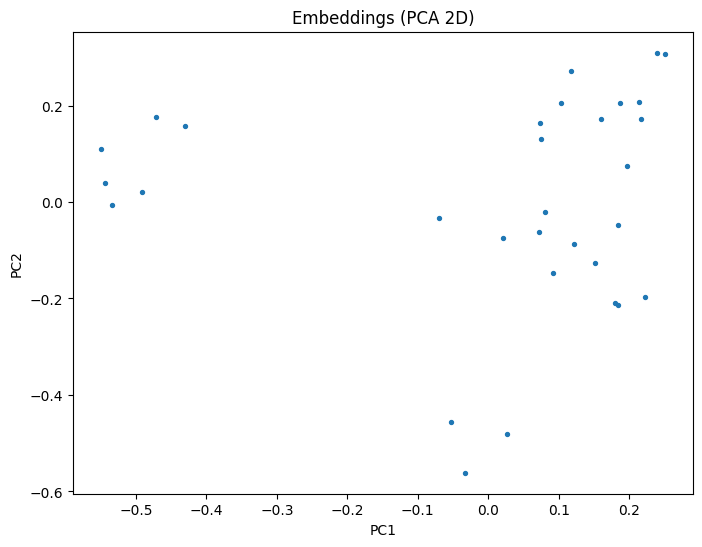

In [49]:
# Optional : To visualize the embeddings using PCA

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA



# embeddings: List[List[float]]
E = np.array(embeddings, dtype=np.float32)

# PCA EMBEDDINGS

print("PCA EMBEDDINGS...\n")
# reduce to 2D
XY = PCA(n_components=2, random_state=0).fit_transform(E)

plt.figure(figsize=(8,6))
plt.scatter(XY[:,0], XY[:,1], s=8)
plt.title("Embeddings (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()